In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy
import PIL
import requests

In [11]:
#Cleaning and preparing data

#Load hospitalization data
hosp_df = pd.read_csv("./public_data/covid_hosp_icu.csv")
#Load deaths data
deaths_df = pd.read_csv("./public_data/covid_deaths.csv")

In [ ]:
#Fix the date strings to read properly as dates (remove time component)
hosp_df['date'] = pd.to_datetime(hosp_df['date']).dt.date
deaths_df['date'] = pd.to_datetime(deaths_df['date']).dt.date

print(hosp_df) #Need to clean columns to get total values for Ontario

         _id        date oh_region icu_current_covid icu_current_covid_vented  \
0      30361  2020-04-01   CENTRAL                46                       34   
1      30362  2020-04-02   CENTRAL                51                       46   
2      30363  2020-04-03   CENTRAL                58                       52   
3      30364  2020-04-04   CENTRAL                57                       49   
4      30365  2020-04-05   CENTRAL                62                       49   
...      ...         ...       ...               ...                      ...   
10195  40556  2024-11-21      WEST                11                        5   
10196  40557  2024-11-22      WEST                11                        5   
10197  40558  2024-11-23      WEST                 9                        4   
10198  40559  2024-11-24      WEST                 9                        3   
10199  40560  2024-11-25      WEST                 8                        3   

       hospitalizations icu

In [ ]:
#After troubleshooting, I learned the ICU variables are non-numeric
print(hosp_df[['hospitalizations']].dtypes)

hospitalizations    int64
dtype: object


In [ ]:
#Convert ICU Variables to Numeric
hosp_df['icu_current_covid'] = pd.to_numeric(hosp_df['icu_current_covid'], errors='coerce')
hosp_df['icu_current_covid_vented'] = pd.to_numeric(hosp_df['icu_current_covid_vented'], errors='coerce')

#Convert to same type as other data
hosp_df = hosp_df.astype({
    'icu_current_covid': 'int64',
    'icu_current_covid_vented': 'int64'
})

In [40]:
#Creating totals for ICU and Hospital Visitations
hosp_total_df = hosp_df.groupby('date', as_index=False).agg({
    'icu_current_covid': 'sum',
    'icu_current_covid_vented': 'sum',
    'hospitalizations': 'sum'
}).reset_index(drop=True)

#Check
print(hosp_total_df.head())

         date  icu_current_covid  icu_current_covid_vented  hospitalizations
0  2020-04-01                167                       112               446
1  2020-04-02                194                       140               475
2  2020-04-03                190                       149               508
3  2020-04-04                200                       154               576
4  2020-04-05                216                       160               597


In [41]:
#Merge the datasets as the goal is to look at hospitalizations against general deaths due to COVID
covid_df = pd.merge(
    hosp_total_df,
    deaths_df,
    on="date",   #Merge on dates because IDs don't line up and this is a series-based analysis
    how="inner"  #Keep only dates present in both datasets
)

#Check columns
print(covid_df.head())

         date  icu_current_covid  icu_current_covid_vented  hospitalizations  \
0  2020-04-01                167                       112               446   
1  2020-04-02                194                       140               475   
2  2020-04-03                190                       149               508   
3  2020-04-04                200                       154               576   
4  2020-04-05                216                       160               597   

    _id  deaths_total  death_covid  death_covid_contrib  death_unknown_missing  
0  1682            17           12                    2                      3  
1  1683            30           24                    2                      4  
2  1684            21           14                    2                      5  
3  1685            30           23                    2                      5  
4  1686            28           19                    3                      6  


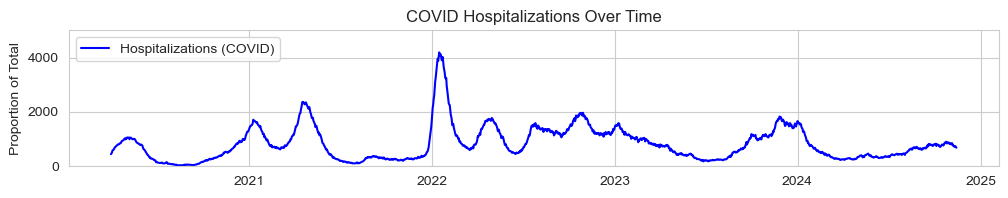

In [ ]:
#General Designing for each single plot

#Plot 1: Hosp
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.subplot(3, 1, 1)  #3 rows, 1 column, 1st subplot

sns.lineplot(
    data=covid_df, 
    x='date', 
    y='hospitalizations', 
    color='blue', 
    linewidth=1.5,
    label='Hospitalizations (COVID)'
)

plt.title('COVID Hospitalizations Over Time', fontsize=12)
plt.xlabel('')
plt.ylabel('Proportion of Total', fontsize=10)
plt.ylim(0, 5000)  
plt.legend(loc='upper left')

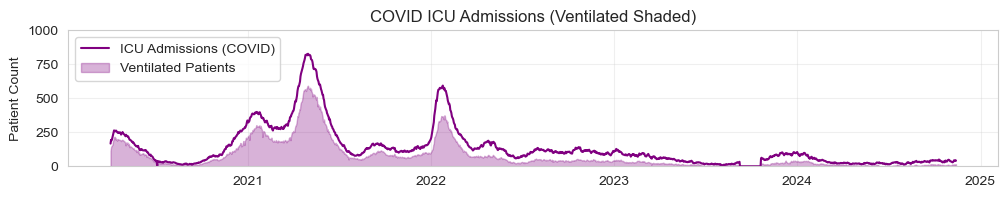

In [ ]:
#Plot 2: ICU (and Ventilated ICU)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.subplot(3, 1, 2)  # Second subplot

#Main ICU line (total COVID patients in ICU)
sns.lineplot(
    data=covid_df,
    x='date',
    y='icu_current_covid',
    color='purple',
    linewidth=1.5,
    label='ICU Admissions (COVID)'
)

#Shaded region for ventilated patients (stacked under main line)
plt.fill_between(
    x=covid_df['date'],
    y1=0,
    y2=covid_df['icu_current_covid_vented'], 
    color='purple',
    alpha=0.3,
    label='Ventilated Patients'
)

plt.title('COVID ICU Admissions (Ventilated Shaded)', fontsize=12)
plt.xlabel('')
plt.ylabel('Patient Count', fontsize=10)
plt.ylim(0, 1000)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

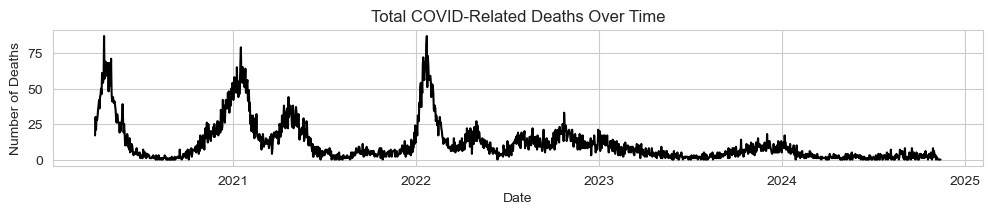

In [ ]:
#Plot 3: Deaths
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.subplot(3, 1, 3)  #Subplot 3

# A line plot of total COVID-related deaths over time
plt.plot(covid_df['date'], 
         covid_df['deaths_total'], 
         color='black',
         linewidth=1.5)
plt.title('Total COVID-Related Deaths Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.show()

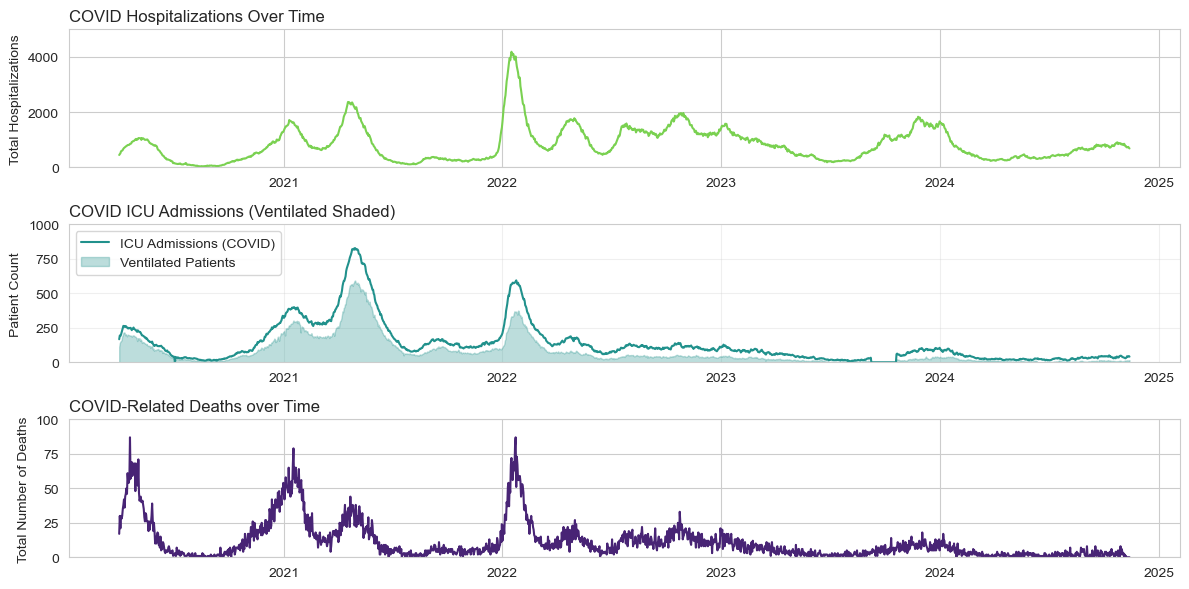

In [52]:
#Here, I'm combining them into 1 plot and experimenting a bit with colors (using the viridis resource from class)


# P1: 
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.subplot(3, 1, 1)  #3 rows, 1 column, 1st subplot

sns.lineplot(
    data=covid_df, 
    x='date', 
    y='hospitalizations', 
    color=plt.cm.viridis(0.8), #Trying out Viridis again! Color scale goes from dark purple to bright yellow [0,1]
    linewidth=1.5,
    label='Hospitalizations (COVID)',
    legend=False
)

plt.title('COVID Hospitalizations Over Time', fontsize=12, loc='left')
plt.xlabel('')
plt.ylabel('Total Hospitalizations', fontsize=10)
plt.ylim(0, 5000)

# P2: 
plt.subplot(3, 1, 2) #Second subplot

#Main ICU line (total COVID patients in ICU)
sns.lineplot(
    data=covid_df,
    x='date',
    y='icu_current_covid',
    color=plt.cm.viridis(0.5),
    linewidth=1.5,
    label='ICU Admissions (COVID)'
)

#Shaded region for ventilated patients (stacked under main line)
plt.fill_between(
    x=covid_df['date'],
    y1=0,
    y2=covid_df['icu_current_covid_vented'], 
    color=plt.cm.viridis(0.5),
    alpha=0.3,
    label='Ventilated Patients'
)

plt.title('COVID ICU Admissions (Ventilated Shaded)', fontsize=12, loc='left')
plt.xlabel('')
plt.ylabel('Patient Count', fontsize=10)
plt.ylim(0, 1000)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# P3: 
plt.subplot(3, 1, 3) #Third subplot

sns.lineplot(
    data=covid_df, 
    x='date', 
    y='deaths_total', 
    color=plt.cm.viridis(0.1), 
    linewidth=1.5,
    label='Total COVID-Related Deaths',
    legend=False
)

plt.title('COVID-Related Deaths over Time', fontsize=12, loc='left')
plt.xlabel('')
plt.ylabel('Total Number of Deaths', fontsize=10)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()